### HuyIGW04 - MLP For Regression Problem

In [2]:
# download MPG Dataset
!gdown --quiet 1qiUDDoYyRLBiKOoYWdFl_5WByHE8Cugu

In [3]:
# lib
import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
# manual seed
random_statement = 59
np.random.seed(random_statement)        # for numpy
torch.manual_seed(random_statement)     # for common pytorch

# set cuda seed
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_statement)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# read the dataset
PATH = './Auto_MPG_data.csv'
data = pd.read_csv(PATH)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Europe        392 non-null    int64  
 8   Japan         392 non-null    int64  
 9   USA           392 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 30.8 KB


- **Non-null data. Some features have INT64 type, others have FLOAT64 type.**

In [6]:
# visualize the head of the samples 
data.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0,1


In [7]:
#  ------  Data Normalization  ------ #

# split features and labels
X = data.iloc[:, 1:]
y = data.iloc[:, :1]

# split into train/val/test sets (this step have to do before normalize data)
X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                test_size=0.2,
                                                random_state=random_statement,
                                                shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train,
                                                    test_size=0.125,
                                                    random_state=random_statement,
                                                    shuffle=True)

# check the number of samples in each split
print(' --- Set Checking --- ')
print('train:', X_train.shape[0])
print('valid:', X_val.shape[0])
print('test:', X_test.shape[0])
print(' -------\n ')

# normalize split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# check normalization process
print(' --- Normalization Checking --- ')
print(X_train[:3, :3])


 --- Set Checking --- 
train: 273
valid: 79
test: 40
 -------
 
 --- Normalization Checking --- 
[[-0.84144139 -1.03791712 -1.03812675]
 [ 0.36757703  0.36824297  0.22296166]
 [-0.84144139 -0.916522   -0.89800582]]


In [8]:
# convert all sets to tensor with consistent dtypes
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [9]:
#  ----- mini-batch training for PyTorch -----  #

# simply custom dataset for training, validation and testing
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)                             # must have in custom set: init, len, getItem

    def __getitem__(self, index):
        return self.X[index], self.y[index]            # return a tuple (feature, label)


# use above class to match X and y.
train_custom = CustomDataset(X_train, y_train)
validation_custom = CustomDataset(X_val, y_val)


# dataloader - for PyTorch mini-batch training
train_set = torch.utils.data.DataLoader(dataset=train_custom,
                                        batch_size=16,
                                        shuffle=True)

val_set = torch.utils.data.DataLoader(dataset=validation_custom,
                                      batch_size=16,
                                      shuffle=False)

In [10]:
# ----------  model constructor ----------- # 

# MLP with 2 hidden layers, ReLU is the activation function.
class MLP(nn.Module):
    def __init__(self, input_features, hidden_dim_01, hidden_dim_02, output_features):
        super().__init__()
        self.linear1 = nn.Linear(input_features, hidden_dim_01)
        self.linear2 = nn.Linear(hidden_dim_01, hidden_dim_02)
        self.output = nn.Linear(hidden_dim_02, output_features)
    
    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        x = F.relu(x)
        out = self.output(x)
        return out      # regression problem return (n,), so dim=1 have to delete.


# initialize a model which based on above constructor.
in_feat = X.shape[1]
hid_feat_01 = 64
hid_feat_02 = 16
out_feat = 1

model = MLP(input_features=in_feat, 
            hidden_dim_01=hid_feat_01, 
            hidden_dim_02=hid_feat_02, 
            output_features=out_feat).to(device)


In [11]:
# ----------- loss & optimizer ------------- #
lr = 1e-4
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [12]:
# ---------- evaluation ------------- #
model.eval()
def R2Score(y_true, y_pred):
    y_true = y_true.to(device)
    y_pred = y_pred.to(device)
    ss_res = torch.sum((y_true - y_pred)**2)        # residual SSE
    y_mean = torch.mean(y_true)
    ss_tot = torch.sum((y_true - y_mean)**2)        # total SSE
    r2 = 1 - ss_res/ss_tot
    return r2

In [13]:
#  ----------- training ----------  #
epochs = 50
losses_train = []
losses_val = []

for epoch in range(epochs):
    losses_train_epoch = []
    losses_val_epoch = []

    model.train()
    for i, (X_train_batch, y_train_batch) in enumerate(train_set):
        X_train_batch = X_train_batch.to(device)
        y_train_batch = y_train_batch.to(device)
        y_hat = model(X_train_batch)
        optimizer.zero_grad()
        loss_train_batch = criterion(y_hat, y_train_batch)
        loss_train_batch.backward()
        optimizer.step()

        # train loss batch
        losses_train_epoch.append(loss_train_batch.item())        
    
    # val loss epoch
    model.eval()
    for j, (X_val_batch, y_val_batch) in enumerate(val_set):
        X_val_batch = X_val_batch.to(device)
        y_val_batch = y_val_batch.to(device)
        y_val_hat = model(X_val_batch)
        loss_val = criterion(y_val_hat, y_val_batch)
        losses_val_epoch.append(loss_val.item())

    loss_val_epoch = sum(losses_val_epoch)/len(losses_val_epoch)
    losses_val.append(loss_val_epoch)

        
    # train loss epoch
    loss_train_epoch = sum(losses_train_epoch)/len(losses_train_epoch)
    losses_train.append(loss_train_epoch)


    # debug
    print(f'EPOCH  {epoch + 1}:   loss_train = {loss_train_epoch},    loss_val = {loss_val_epoch}')


EPOCH  1:   loss_train = 597.4238772922092,    loss_val = 610.428662109375
EPOCH  2:   loss_train = 584.1498514811198,    loss_val = 601.2608154296875
EPOCH  3:   loss_train = 563.3935877482096,    loss_val = 590.381982421875
EPOCH  4:   loss_train = 553.7858632405599,    loss_val = 576.4977172851562
EPOCH  5:   loss_train = 530.6283704969618,    loss_val = 558.2908935546875
EPOCH  6:   loss_train = 585.6309560139974,    loss_val = 528.9980834960937
EPOCH  7:   loss_train = 477.88847096761066,    loss_val = 492.13067626953125
EPOCH  8:   loss_train = 448.6760033501519,    loss_val = 437.2662780761719
EPOCH  9:   loss_train = 378.8037626478407,    loss_val = 368.3057434082031
EPOCH  10:   loss_train = 318.2962994045681,    loss_val = 276.5989166259766
EPOCH  11:   loss_train = 232.77811601426868,    loss_val = 179.50765991210938
EPOCH  12:   loss_train = 132.04530673556857,    loss_val = 108.57828369140626
EPOCH  13:   loss_train = 90.38914065890842,    loss_val = 65.1503303527832
EPOCH

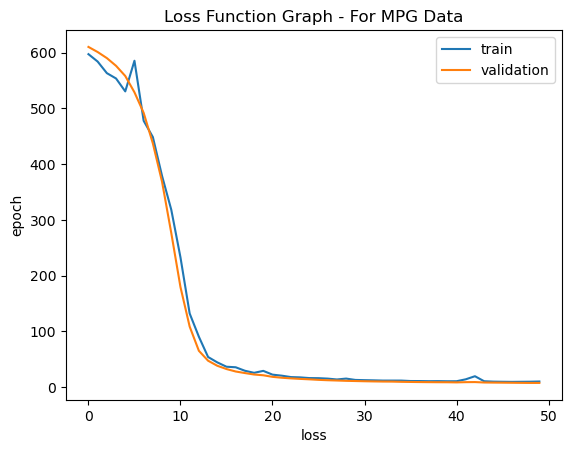

In [14]:
plt.title('Loss Function Graph - For MPG Data')
plt.plot(losses_train, label='train')
plt.plot(losses_val, label='validation')
plt.xlabel('loss')
plt.ylabel('epoch')
plt.legend()
plt.show()

In [15]:
model.eval()
with torch.no_grad():
    X_test = X_test.to(device)
    y_test = y_test.to(device)
    y_hat_test = model(X_test)
    r2_test = R2Score(y_test, y_hat_test).item()
    print(f'Evaluation of test set: {round(r2_test, 3)}/1.00')

Evaluation of test set: 0.861/1.00
